# Nested CV — Top 3 Regressors

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV,
    cross_val_predict, train_test_split, cross_val_score,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = [
    'movie_id', 'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic'] = 0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left'); syn_mov['is_synthetic'] = 1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Combined: {len(df_all)} movies × {len(df_all.columns)} cols')

Combined: 50 movies × 343 cols


In [ ]:

DROP = {'movie_id', 'condition', 'n_participants',
        'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
        'is_synthetic'}
df_feat = df_all.copy()

ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD_MAP)

OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std() == 0].tolist())
feature_cols = list(X_all.columns)
print(f'Final feature matrix: {X_all.shape}')

Final feature matrix: (50, 360)


# Nested CV helper

In [ ]:
from sklearn.base import clone

def nested_cv(pipeline_factory, param_grid, X, y, n_outer=5, n_inner=5,
              scoring='neg_mean_absolute_error', name=''):
    """
    Proper nested cross-validation:
      - Outer K-fold splits into train/test.
      - Inside each outer fold, GridSearchCV does hyperparameter tuning
        using inner K-fold on the OUTER TRAIN set ONLY.
      - Best model per outer fold predicts on the outer TEST set
        (which the inner tuning has never seen).

    Returns:
      out_predictions: array same length as y, with per-sample predictions
                       from the outer fold in which they were the test set.
      best_params_per_fold: list of best param dicts (one per outer fold).
      metrics: dict of aggregated R², MAE, RMSE, Spearman, Pearson.
    """
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=42)
    inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=42)

    out_pred = np.empty(len(y))
    out_pred[:] = np.nan
    fold_params = []

    for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        pipe = pipeline_factory()
        search = GridSearchCV(pipe, param_grid, cv=inner_cv,
                              scoring=scoring, n_jobs=-1, refit=True)
        search.fit(X_tr, y_tr)
        out_pred[test_idx] = search.best_estimator_.predict(X_te)
        fold_params.append(search.best_params_)
        print(f'  Outer fold {fold_i+1}/{n_outer}: best_params={search.best_params_}')

    metrics = {
        'r2':       r2_score(y, out_pred),
        'mae':      mean_absolute_error(y, out_pred),
        'rmse':     np.sqrt(mean_squared_error(y, out_pred)),
        'spearman': spearmanr(y, out_pred).correlation,
        'pearson':  pearsonr(y, out_pred)[0],
    }
    print(f'\n{name}: R²={metrics["r2"]:.3f}, MAE={metrics["mae"]:.3f}, '
          f'Spearman ρ={metrics["spearman"]:.3f}')
    return out_pred, fold_params, metrics

# Random Forest (nested CV)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def make_rf():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ])

rf_grid = {
    'model__n_estimators':    [200, 500],
    'model__max_depth':       [3, 5, 7, None],
    'model__min_samples_leaf':[1, 2, 4],
    'model__max_features':   ['sqrt', 0.3, 0.5],
}

print('=== RANDOM FOREST — IMDb (nested CV) ===')
rf_imdb_pred, rf_imdb_params, rf_imdb_m = nested_cv(
    make_rf, rf_grid, X_all, y_imdb_all, name='RF-IMDb')

print('\n=== RANDOM FOREST — WOM (nested CV) ===')
rf_wom_pred, rf_wom_params, rf_wom_m = nested_cv(
    make_rf, rf_grid, X_all, y_wom_all, name='RF-WOM')

=== RANDOM FOREST — IMDb (nested CV) ===
  Outer fold 1/5: best_params={'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 500}
  Outer fold 2/5: best_params={'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
  Outer fold 3/5: best_params={'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
  Outer fold 4/5: best_params={'model__max_depth': 3, 'model__max_features': 0.3, 'model__min_samples_leaf': 4, 'model__n_estimators': 500}
  Outer fold 5/5: best_params={'model__max_depth': 5, 'model__max_features': 0.3, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

RF-IMDb: R²=0.492, MAE=0.318, Spearman ρ=0.643

=== RANDOM FOREST — WOM (nested CV) ===
  Outer fold 1/5: best_params={'model__max_depth': 3, 'model__max_features': 0.3, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
  Outer fold 2/5: bes

# Gradient Boosting (nested CV)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

def make_gbm():
    return Pipeline([
        ('model', HistGradientBoostingRegressor(random_state=42)),
    ])

gbm_grid = {
    'model__learning_rate':     [0.01, 0.05, 0.1],
    'model__max_iter':          [100, 200, 400],
    'model__max_depth':         [3, 5, None],
    'model__min_samples_leaf':  [4, 10],
    'model__l2_regularization': [0.0, 1.0, 10.0],
}

print('=== GRADIENT BOOSTING — IMDb (nested CV) ===')
gbm_imdb_pred, gbm_imdb_params, gbm_imdb_m = nested_cv(
    make_gbm, gbm_grid, X_all, y_imdb_all, name='GBM-IMDb')

print('\n=== GRADIENT BOOSTING — WOM (nested CV) ===')
gbm_wom_pred, gbm_wom_params, gbm_wom_m = nested_cv(
    make_gbm, gbm_grid, X_all, y_wom_all, name='GBM-WOM')

=== GRADIENT BOOSTING — IMDb (nested CV) ===
  Outer fold 1/5: best_params={'model__l2_regularization': 10.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 100, 'model__min_samples_leaf': 10}
  Outer fold 2/5: best_params={'model__l2_regularization': 10.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 400, 'model__min_samples_leaf': 10}
  Outer fold 3/5: best_params={'model__l2_regularization': 10.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 200, 'model__min_samples_leaf': 10}
  Outer fold 4/5: best_params={'model__l2_regularization': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400, 'model__min_samples_leaf': 10}
  Outer fold 5/5: best_params={'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 400, 'model__min_samples_leaf': 4}

GBM-IMDb: R²=0.369, MAE=0.341, Spearman ρ=0.609

=== GRADIENT BOOSTING — WOM (nested CV) ===
  

# PLS (nested CV)

In [ ]:
from sklearn.cross_decomposition import PLSRegression

def make_pls():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', PLSRegression(scale=False)),
    ])

pls_grid = {'model__n_components': list(range(1, 16))}

print('=== PLS — IMDb (nested CV) ===')
pls_imdb_pred, pls_imdb_params, pls_imdb_m = nested_cv(
    make_pls, pls_grid, X_all, y_imdb_all, name='PLS-IMDb')

print('\n=== PLS — WOM (nested CV) ===')
pls_wom_pred, pls_wom_params, pls_wom_m = nested_cv(
    make_pls, pls_grid, X_all, y_wom_all, name='PLS-WOM')

=== PLS — IMDb (nested CV) ===
  Outer fold 1/5: best_params={'model__n_components': 1}
  Outer fold 2/5: best_params={'model__n_components': 3}
  Outer fold 3/5: best_params={'model__n_components': 2}
  Outer fold 4/5: best_params={'model__n_components': 3}
  Outer fold 5/5: best_params={'model__n_components': 3}

PLS-IMDb: R²=0.427, MAE=0.329, Spearman ρ=0.649

=== PLS — WOM (nested CV) ===
  Outer fold 1/5: best_params={'model__n_components': 1}
  Outer fold 2/5: best_params={'model__n_components': 1}
  Outer fold 3/5: best_params={'model__n_components': 1}
  Outer fold 4/5: best_params={'model__n_components': 1}
  Outer fold 5/5: best_params={'model__n_components': 1}

PLS-WOM: R²=0.190, MAE=0.402, Spearman ρ=0.385


# Comparison table normal CV vs nested CV

In [ ]:

v2 = {
    'RF-IMDb':  {'r2': 0.544, 'spearman': 0.683, 'mae': 0.302},
    'RF-WOM':   {'r2': 0.207, 'spearman': 0.415, 'mae': 0.380},
    'GBM-IMDb': {'r2': 0.476, 'spearman': 0.712, 'mae': 0.326},
    'GBM-WOM':  {'r2': 0.136, 'spearman': 0.364, 'mae': 0.395},
    'PLS-IMDb': {'r2': 0.472, 'spearman': 0.680, 'mae': 0.309},
    'PLS-WOM':  {'r2': 0.190, 'spearman': 0.385, 'mae': 0.402},
}

nested_metrics = {
    'RF-IMDb':  rf_imdb_m,  'RF-WOM':  rf_wom_m,
    'GBM-IMDb': gbm_imdb_m, 'GBM-WOM': gbm_wom_m,
    'PLS-IMDb': pls_imdb_m, 'PLS-WOM': pls_wom_m,
}

rows = []
for k in v2:
    rows.append({
        'Model_Target':  k,
        'v2_R²':         v2[k]['r2'],
        'nested_R²':     nested_metrics[k]['r2'],
        'Δ R²':          nested_metrics[k]['r2'] - v2[k]['r2'],
        'v2_ρ':          v2[k]['spearman'],
        'nested_ρ':      nested_metrics[k]['spearman'],
        'Δ ρ':           nested_metrics[k]['spearman'] - v2[k]['spearman'],
    })
comparison = pd.DataFrame(rows)
print('Nested CV vs v2 (leaky) — negative deltas confirm leakage was small:')
display(comparison.round(3))

Nested CV vs v2 (leaky) — negative deltas confirm leakage was small:


,Model_Target,v2_R²,nested_R²,Δ R²,v2_ρ,nested_ρ,Δ ρ
0,RF-IMDb,0.544,0.492,-0.052,0.683,0.643,-0.040
1,RF-WOM,0.207,0.174,-0.033,0.415,0.377,-0.038
2,GBM-IMDb,0.476,0.369,-0.107,0.712,0.609,-0.103
3,GBM-WOM,0.136,0.079,-0.057,0.364,0.261,-0.103
4,PLS-IMDb,0.472,0.427,-0.045,0.680,0.649,-0.031
5,PLS-WOM,0.190,0.190,-0.000,0.385,0.385,0.000


# Visualisation

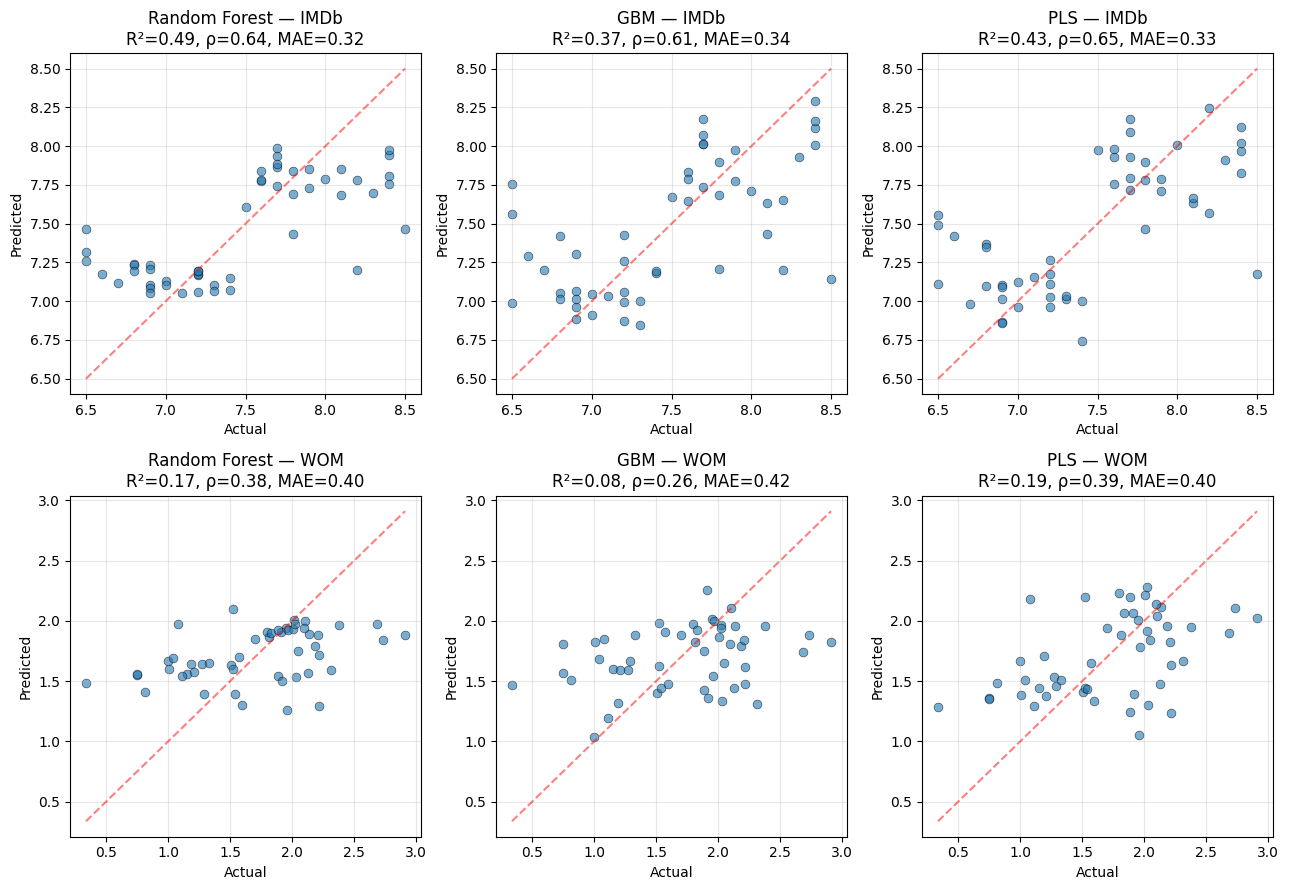

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
configs = [
    ('Random Forest — IMDb', y_imdb_all, rf_imdb_pred,  rf_imdb_m),
    ('GBM — IMDb',           y_imdb_all, gbm_imdb_pred, gbm_imdb_m),
    ('PLS — IMDb',           y_imdb_all, pls_imdb_pred, pls_imdb_m),
    ('Random Forest — WOM',  y_wom_all,  rf_wom_pred,   rf_wom_m),
    ('GBM — WOM',            y_wom_all,  gbm_wom_pred,  gbm_wom_m),
    ('PLS — WOM',            y_wom_all,  pls_wom_pred,  pls_wom_m),
]
for ax, (name, y_t, y_p, m) in zip(axes.flat, configs):
    ax.scatter(y_t, y_p, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nR²={m["r2"]:.2f}, ρ={m["spearman"]:.2f}, MAE={m["mae"]:.2f}')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
out = {
    'task': 'nested_cv_top3_regressors',
    'cv_strategy': 'outer 5-fold + inner 5-fold (no hyperparameter leakage)',
    'feature_count': len(feature_cols),
    'metrics': {
        'rf_imdb':  rf_imdb_m,  'rf_wom':  rf_wom_m,
        'gbm_imdb': gbm_imdb_m, 'gbm_wom': gbm_wom_m,
        'pls_imdb': pls_imdb_m, 'pls_wom': pls_wom_m,
    },
    'best_params_per_outer_fold': {
        'rf_imdb':  rf_imdb_params,  'rf_wom':  rf_wom_params,
        'gbm_imdb': gbm_imdb_params, 'gbm_wom': gbm_wom_params,
        'pls_imdb': pls_imdb_params, 'pls_wom': pls_wom_params,
    },
}
out_path = RUN_DIR / 'results_nested_cv_finals.json'
with open(out_path, 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3/results_nested_cv_finals.json
